In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import seaborn as sns
import mosek
import matplotlib.pyplot as plt
import datetime as date
from datetime import datetime as dt
from dateutil.relativedelta import *
import scipy.stats
from scipy.stats import rankdata

In [2]:
################ all h functions evaluation

def h_quad(x,par):
    return((1+par)*x-par*x**2)

def h_single_power(x,par):
    return(1-(np.abs(1-x))**par)

def h_double_power(x,par):
    return((1-(np.abs(1-x))**par)**(1/par))

def h_pow(x,par):
    return(x**par)

def h_logarithm(x,par):
    return(x**par*(1-np.log(x**r)))


In [3]:
################ all phi functions constraints

def modified_chi2(p,q,r,par,constraints):
    N = p.shape[0]
    phi_cons = 0
    for i in range(N):
        phi_cons = phi_cons + 1/p[i]*(q[i]-p[i])**2
    constraints.append(phi_cons<=r)
    return(constraints)

def kullback_leibler(p,q,r,par,constraints):
    N = p.shape[0]
    phi_cons = 0
    for i in range(N):
        phi_cons = phi_cons -cp.entr(q[i]) - q[i]*np.log(p[i])
    constraints.append(phi_cons<=r)
    return(constraints)

In [4]:
############### all h functions constraints

def h_quadratic(q_b,q,rank,par,constraints):
    N = q.shape[0]
    for i in range(N-1):
        v = (1+par)*cp.sum(q[rank[0:i+1]])-par*cp.sum(q[rank[0:i+1]])**2
        constraints.append(cp.sum(q_b[rank[0:i+1]])-v <= 0)
    return(constraints)

def h_sing_power(q_b,q,rank,par,constraints):
    N = q.shape[0]
    for i in range(N-1):
        v = 1-cp.power((1-cp.sum(q[rank[0:i+1]])),par)
        constraints.append(cp.sum(q_b[rank[0:i+1]])-v <= 0)
    return(constraints)

def h_doub_power(q_b,q,rank,par,constraints):
    N = q.shape[0]
    u1 = cp.Variable(N, nonneg = True)
    u2 = cp.Variable(N, nonneg = True)
    t = cp.Variable(N)
    constraints.append(u1<=1)
    for i in range(N-1):
        constraints.append(cp.sum(q_b[rank[0:i+1]])+t[i]<=0)
        constraints.extend((u2[i]>=-t[i],u1[i]>= 1-cp.sum(q[rank[0:i+1]])))
        constraints.append(cp.power(u1[i],par)+cp.power(u2[i],par) <= 1)
    return(constraints)

def h_power(q_b,q,rank,par,constraints):
    N = q.shape[0]
    for i in range(N-1):
        constraints.append(cp.sum(q_b[rank[0:i+1]])-cp.power(cp.sum(q[rank[0:i+1]]),par) <= 0)
    return(constraints)

def h_log(q_b,q,rank,par,constraints):
    N = q.shape[0]
    u1 = cp.Variable(N, nonneg = True)
    t = cp.Variable(N)
    constraints.append(u1<=1)
    for i in range(N-1):
        constraints.append(cp.sum(q_b[rank[0:i+1]])+t[i]<=0)
        constraints.append(-u1[i]-cp.entr(u1[i])<= t[i])
        constraints.append(u1[i]-cp.power(cp.sum(q[rank[0:i+1]]),par) <= 0)
    return(constraints)

In [5]:
############## all phi conjugates

def modified_chi2_conj(gamma, s,t, constraints):
    N = s.shape[0]
    w = cp.Variable(N, nonneg = True)
    for i in range(N):
        constraints.append(cp.norm(cp.vstack([w[i],t[i]/2]))<=(t[i]+2*gamma)/2)
    constraints.append(s/2+gamma*(np.zeros(N)+1)<= w)
    return(constraints)

def kullback_leibler_conj(gamma,s,t,constraints):
    N = s.shape[0]
    w = cp.Variable(N)
    constraints.append(w - gamma*(np.zeros(N)+1) <= t)
    for i in range(N):
        constraints.append(cp.kl_div(gamma,w[i])+gamma+s[i]-w[i]<= 0)
    return(constraints)

In [6]:
############## all h conjugates

def h_quad_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    eta = cp.Variable(M, nonneg= True)
    for j in range(M):
        constraints.append(cp.norm(cp.vstack([eta[j],(z[j]-lbda[j])/2]))<=(z[j]+lbda[j])/2)
        constraints.append(1/(2*np.sqrt(par))*(-v[j]+lbda[j]+par*lbda[j])<= eta[j])
    return(constraints)

def h_sing_power_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    xi_2 = cp.Variable(M, nonneg = True)
    xi_3 = cp.Variable(M, nonneg = True)
    xi_4 = cp.Variable(M, nonneg = True)
    constraints.extend((xi_3 <= xi_2, xi_3 <= v))
    constraints.append(lbda-xi_3+(par**(-1/(par-1))-par**(-par/(par-1)))*xi_4 <= z)
    exponent = np.array([(par-1)/par,1-(par-1)/par])
    for j in range(M):
        constraints.append(xi_2[j]-cp.geo_mean(cp.vstack([xi_4[j],lbda[j]]),exponent)<= 0)
    return(constraints)

def h_doub_power_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    xi_2 = cp.Variable(M, nonneg = True)
    xi_3 = cp.Variable(M, nonneg = True)
    constraints.extend((xi_2 >= lbda, -v + xi_3 <=0))
    exp = par/(par-1)
    for j in range(M):
        constraints.append(-xi_3[j]+cp.pnorm(cp.vstack([xi_2[j],xi_3[j]]),exp)<= z[j])
    return(constraints)

def h_power_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    constraints.append(v >= 0)
    const = (par**(par/(1-par))-par**(1/(1-par)))**(1-par)
    exp = np.array([1-par, par])
    for j in range(M):
        constraints.append(cp.geo_mean(cp.vstack([z[j],v[j]]),exp)>= lbda[j]*const)
    return(constraints)

def h_log_conj(lbda,v,z,par,constraints):
    M = lbda.shape[0]
    xi_1 = cp.Variable(M, nonneg = True)
    xi_2 = cp.Variable(M, nonneg = True)
    xi_3 = cp.Variable(M, nonneg = True)
    xi_4 = cp.Variable(M, nonneg = True)
    const = (par**(par/(1-par))-par**(1/(1-par)))
    constraints.extend((v >= 0, xi_3 + xi_1 + const* xi_4 <= z))
    exp = np.array([par, 1-par])
    for j in range(M):
        constraints.append(xi_2[j]+xi_3[j] >= cp.kl_div(lbda[j],xi_1[j]) +lbda[j]-xi_1[j])
        constraints.append(xi_2[j] <= cp.geo_mean(cp.vstack([v[j],xi_4[j]]),exp))
    return(constraints)
    

In [7]:
############### all utility functions

def lin_utility(R,a,r_f,par):
    return(R@a + (1-cp.sum(a))*r_f)

def lin_utility_eva(R,a,r_f,par):
    return(R.dot(a)+(1-sum(a))*r_f)
    

In [8]:
############## all set operations

def ranktoset (A):
    A = list(A)
    sets = [[A[0]]]
    for i in range(1,len(A)):
        new = A[0:i+1]
        sets.append(new)
    return(sets)

def makesetflex (A, B):    # we assume A is non-empty
    N = len(A)
    B = list(B)
    M = len(B)
    added = []
    for i in range(M):
        new = B[0:i+1]
        for k in range(N):
            if len(A[k])==len(new) and len(np.intersect1d(A[k],new))==len(new):
                break
            if k == N-1:
                A.append(new)
                added.append(new)
    return(A,added)

In [9]:
############### robust_counterpart and robustness check


def robust_counterpart(sets,p,R,r,par,r_f,c,phi_conj, h_conj,utility):
    N = len(p)
    I = len(R[0])
    M = len(sets)
    v = cp.Variable(M)
    lbda = cp.Variable(M, nonneg = True)
    a = cp.Variable(I)
    alpha = cp.Variable(1)
    beta = cp.Variable(1)
    gamma = cp.Variable(1,nonneg = True)
    t = cp.Variable(N)
    z = cp.Variable(M)
    s = cp.Variable(N)
    constraints = [cp.abs(a)<= 10]
    for i in range(N):
        lbdasum = 0
        vsum = 0
        for j in range(M):
            if i in sets[j]:
                lbdasum = lbdasum + lbda[j]
                vsum = vsum + v[j]
        constraints.append(-utility(R,a,r_f,par)[i] - lbdasum - beta <= 0)
        constraints.append(s[i] == -alpha + vsum)
    constraints = phi_conj(gamma,s,t,constraints)
    constraints = h_conj(lbda,v,z,par,constraints)
    constraints.append(alpha + beta + gamma * r  + cp.sum(z) + p@t <= c)
    obj = cp.Maximize((utility(R,a,r_f,par)).T @ p)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(a.value, prob.value)
    
def robustcheck(a,R,r,p,par,r_f,h_func, phi_func,utility, utility_eva):
    N = len(p)
    x = -utility_eva(R,a,r_f,par)
    rank = np.argsort((-x))
    q_b = cp.Variable(N, nonneg = True)
    q = cp.Variable(N, nonneg=True)
    constraints = [cp.sum(q) == 1, cp.sum(q_b)==1]
    constraints = h_func(q_b,q,rank,par,constraints)
    constraints = phi_func(p,q,r,par,constraints)
    obj = cp.Maximize(-q_b.T @ utility(R,a,r_f,par))
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(prob.value,q_b.value)



In [10]:
################### final algorithm

def squeeze_algorithm(R,r,c,p,par,r_f,h_eva, phi_func,h_func,phi_conj,h_conj,utility):
    N = len(p)
    I = len(R[0])
    a = cp.Variable(I)
    constraints = [cp.abs(a)<=10]
    h = np.zeros(N)
    iterations = 0
    steps = 0
    for i in range(N-1):
        h[i] = h_eva(sum(p[i:N]),par)-h_eva(sum(p[i+1:N]),par)
    h[N-1]=h_eva(p[N-1],par)
    constraints.append(-h.T @ utility(R,a,r_f,par)<= c)
    obj = cp.Maximize((utility(R,a,r_f,par)).T @ p)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    w = a.value
    upperobj = prob.value
    nonstop = True
    lowerobj_old = -np.inf
    while nonstop:
        [rbvalue,h] = robustcheck(w,R,r,p,par,r_f,h_func,phi_func,utility,utility_eva)
        #print('rbvalue',rbvalue)
        if rbvalue <= c+1e-4:
            oldrank = np.argsort(R.dot(w))
            sets = ranktoset(oldrank)
            while nonstop:
                [w,lowerobj] = robust_counterpart(sets,p,R,r,par,r_f,c,phi_conj,h_conj,utility)
                break
                #print('new',lowerobj)
                newrank = np.argsort(R.dot(w))
                if np.array_equal(newrank,oldrank):
                    break
                if lowerobj - lowerobj_old <= 1e-5:
                    break
                [sets,added] = makesetflex(sets,newrank)
                oldrank = newrank
                steps = steps + 1
            return(w, upperobj, lowerobj, iterations,steps)
        constraints.append(-h.T @ utility(R,a,r_f,par)<= c)
        iterations = iterations + 1
        prob = cp.Problem(obj,constraints)
        prob.solve(solver=cp.MOSEK)
        w = a.value
        upperobj = prob.value
        #print('cut-iterations', iterations)

In [11]:
def non_robust_cut_check(a,R,p,par,r_f, utility_eva, utility, h_func):
    N = len(p)
    x = -utility_eva(R,a,r_f,par)
    rank = np.argsort((-x))
    q_b = cp.Variable(N, nonneg = True)
    constraints = [cp.sum(q_b)==1]
    constraints = h_func(q_b,p,rank,par,constraints)
    obj = cp.Maximize(-q_b.T @ utility(R,a,r_f,par))
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(prob.value,q_b.value)


def non_robust_cut(R,c,p,par,r_f, h_eva,h_func, utility, utility_eva):
    N = len(p)
    I = len(R[0])
    a = cp.Variable(I)
    constraints = [cp.abs(a)<=10]
    h = np.zeros(N)
    iterations = 0
    for i in range(N-1):
        h[i] = h_eva(sum(p[i:N]),par)-h_eva(sum(p[i+1:N]),par)
    h[N-1]=h_eva(p[N-1],par)
    constraints.append(-h.T @ utility(R,a,r_f,par)<= c)
    obj = cp.Maximize((utility(R,a,r_f,par)).T @ p)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    upperobj = prob.value
    w = a.value
    nonstop = True
    while nonstop:
        [rbvalue,h] = non_robust_cut_check(w,R,p,par,r_f, utility_eva, utility, h_func)
        #print('rbvalue',rbvalue)
        if rbvalue <= c +1e-3:
            return(w,'upperbound', upperobj, 'cut-iterations', iterations)
        constraints.append(-h.T @ utility(R,a,r_f,par)<= c)
        iterations = iterations + 1
        prob = cp.Problem(obj,constraints)
        prob.solve(solver=cp.MOSEK)
        w = a.value
        upperobj = prob.value
        #print('cut-iterations', iterations)

In [12]:
def Ex_return(q,R,w,r_f,par,utility_eva):
    x = utility_eva(R,w,r_f,par)
    ret = q.dot(x)
    return(ret)

def risk_calc(q,R,w,r_f,par,utility_eva, h_eva):
    N = len(q)
    x = -utility_eva(R,w,r_f,par)
    rank = np.argsort((-x))
    h = np.zeros(N)
    risk = h_eva(q[rank[0]],par)*x[rank[0]]
    for i in range(1,N-1):
        weight = h_eva(sum(q[rank[0:i+1]]),par)-h_eva(sum(q[rank[0:i]]),par)
        risk = risk + weight*x[rank[i]]
    weight = 1-h_eva(sum(q[rank[0:N-1]]),par)
    risk = risk + weight*x[rank[N-1]]
    return(risk)

In [13]:
df_returns6 = pd.read_csv('6_Portfolios_2x3.csv', skiprows = 15)

In [14]:
df_returns = df_returns6[0:1144].copy()
df_returns['Date'] = pd.to_datetime(df_returns['Date'], format = '%Y%m')
for i in range(1, len(df_returns.columns)):
    df_returns[df_returns.columns[i]] = pd.to_numeric(df_returns[df_returns.columns[i]])
df_returns

,Date,SMALL LoBM,ME1 BM2,SMALL HiBM,BIG LoBM,ME2 BM2,BIG HiBM
0,1926-07-01,1.0874,0.9349,-0.0695,5.7168,1.9620,1.4222
1,1926-08-01,0.7030,1.2300,5.3842,2.7154,2.6930,6.3154
2,1926-09-01,-2.9117,-0.1303,-0.4374,1.4287,0.0704,-0.7967
3,1926-10-01,-3.8196,-4.5860,-2.0112,-3.5898,-2.3398,-4.0970
4,1926-11-01,3.1806,3.7233,2.0944,3.1292,2.8952,3.4614
...,...,...,...,...,...,...,...
1139,2021-06-01,5.6058,0.4400,-1.0979,4.8188,-1.2594,-4.0036
1140,2021-07-01,-5.5593,-1.8623,-3.6521,3.1048,-0.0099,-2.3000
1141,2021-08-01,2.3903,1.5124,2.6680,3.5667,1.4122,3.0371
1142,2021-09-01,-4.3421,-3.4661,0.6445,-5.4525,-3.8570,-0.2526


In [15]:
startdate = dt(1984,1,3)
enddate = dt(2014,1,3)
X = df_returns[np.logical_and(df_returns.Date >= startdate, df_returns.Date <= enddate )][df_returns.columns[1:7]]
X = X.reset_index(drop = True)
R = X.to_numpy()

In [19]:
N=R.shape[0]
p = np.zeros(N)+1/N
I = R.shape[1]
par = 2
phi_dot = 1
r = phi_dot/(2*N)*scipy.stats.chi2.ppf(0.95, N)   # this is the parameter of the h function min(1, p/(1-m))
r_f = 0.07
c = 5
h_eva = h_single_power
phi_func = kullback_leibler
h_func = h_sing_power
phi_conj = kullback_leibler_conj
h_conj = h_sing_power_conj
utility= lin_utility
utility_eva = lin_utility_eva

In [97]:
robust_result = squeeze_algorithm(R,r,c,p,par,r_f,h_eva, phi_func,h_func,phi_conj,h_conj,utility)
print(robust_result)
w_rob = robust_result[0]

rbvalue 963.2311770162837
cut-iterations 1
rbvalue 212.5321292284443
cut-iterations 2
rbvalue 113.23165493830955
cut-iterations 3
rbvalue 74.40109291365047
cut-iterations 4
rbvalue 34.180082051915306
cut-iterations 5
rbvalue 46.934414340347764
cut-iterations 6
rbvalue 22.849866823667135
cut-iterations 7
rbvalue 41.661544796465634
cut-iterations 8
rbvalue 9.535190728068045
cut-iterations 9
rbvalue 8.847159369976298
cut-iterations 10
rbvalue 7.262617247570911
cut-iterations 11
rbvalue 7.291725819950418
cut-iterations 12
rbvalue 6.270582807222162
cut-iterations 13
rbvalue 6.367164364358796
cut-iterations 14
rbvalue 5.750281877649472
cut-iterations 15
rbvalue 5.549564857218316
cut-iterations 16
rbvalue 5.4345518518787514
cut-iterations 17
rbvalue 5.910840375595579
cut-iterations 18
rbvalue 5.729869670796159
cut-iterations 19
rbvalue 5.340300453829128
cut-iterations 20
rbvalue 5.677859677590652
cut-iterations 21
rbvalue 5.271984503794365
cut-iterations 22
rbvalue 5.331768797957208
cut-itera

In [98]:
results_nonrb = non_robust_cut(R,c,p,par,r_f, h_eva,h_func, utility, utility_eva)
print(results_nonrb)
w_notrob = results_nonrb[0]
robustcheck(results_nonrb[0],R,r,p,par,r_f,h_func, phi_func,utility, utility_eva)[0]

rbvalue 345.9922825738966
cut-iterations 1
rbvalue 44.02957123497427
cut-iterations 2
rbvalue 31.59948175154739
cut-iterations 3
rbvalue 21.0346162828671
cut-iterations 4
rbvalue 26.675296287783063
cut-iterations 5
rbvalue 20.68431518088053
cut-iterations 6
rbvalue 15.56758245534547
cut-iterations 7
rbvalue 11.504609129392437
cut-iterations 8
rbvalue 11.159718457764615
cut-iterations 9
rbvalue 9.110920462206328
cut-iterations 10
rbvalue 7.193022054283383
cut-iterations 11
rbvalue 7.350298847551086
cut-iterations 12
rbvalue 7.29918344906876
cut-iterations 13
rbvalue 6.091310268715737
cut-iterations 14
rbvalue 6.009973490947971
cut-iterations 15
rbvalue 5.97613271924405
cut-iterations 16
rbvalue 8.936004272963558
cut-iterations 17
rbvalue 6.0097576960977115
cut-iterations 18
rbvalue 5.617171485052455
cut-iterations 19
rbvalue 5.680061814070198
cut-iterations 20
rbvalue 5.454448298854237
cut-iterations 21
rbvalue 5.380777097281349
cut-iterations 22
rbvalue 5.341257916893908
cut-iterations

13.709722915255936

In [17]:
prob = []
N = R.shape[0]
mean = 1/N
var = np.sqrt(0.3/(N**2))
for i in range(5000):
    q_real = np.zeros(N)
    for j in range(N-1):
        continu = True
        while continu == True:
            q = np.random.normal(mean,var)
            if q>= 0:
                continu = False
                q_real[j] = q
    last = 1-np.sum(q_real[0:N-1])
    if last >= 0:
        q_real[N-1] = last
        prob.append(q_real)

In [20]:
risk_level = np.array([0.01,0.5,10])#np.array([0.01,0.05,0.08,0.3,0.5,0.8,1,5,7,10,20])
L = len(risk_level)
returns = np.zeros(L)
gap = np.zeros(L)
num_iter = np.zeros(L)
w_rob = []
w_notrob = []
for i in range(L):
    print(i)
    robust_result = squeeze_algorithm(R,r,risk_level[i],p,par,r_f,h_eva, phi_func,h_func,phi_conj,h_conj,utility)
    gap[i] = robust_result[1]-robust_result[2]
    num_iter[i] = robust_result[3]
    returns[i] = robust_result[2]
    if risk_level[i] in [0.01,0.05,0.5,1,5,10]:
        w_rob.append(robust_result[0])
        results_nonrb = non_robust_cut(R,risk_level[i],p,par,r_f, h_eva,h_func, utility, utility_eva)
        w_notrob.append(results_nonrb[0])

0
1
2


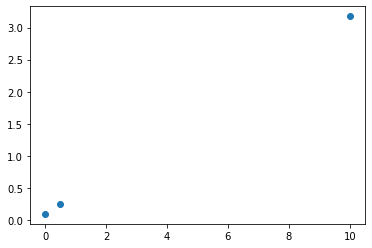

In [21]:
plt.plot(risk_level, returns, 'o')

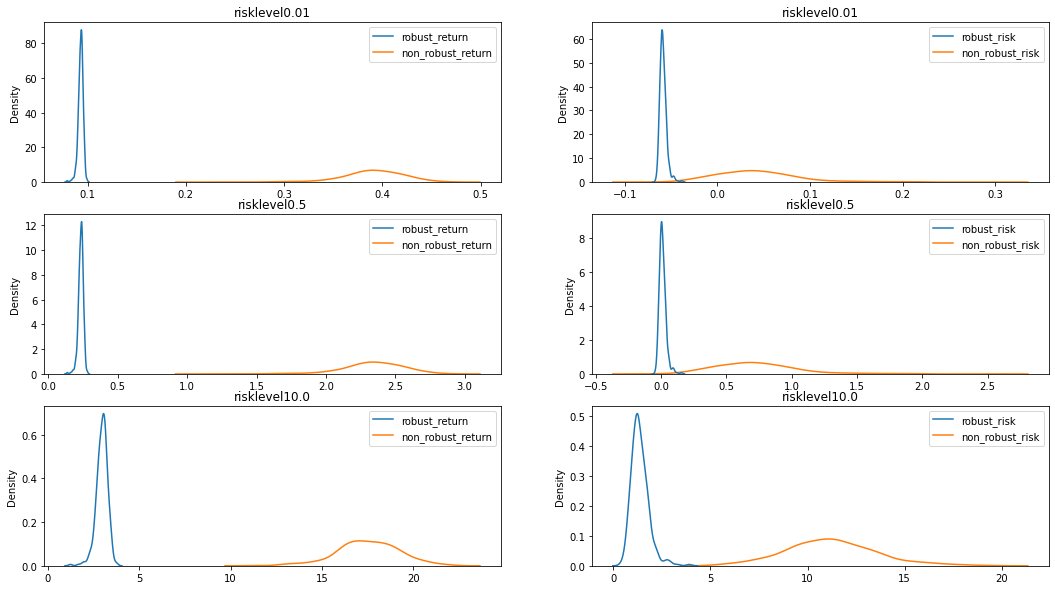

In [44]:
risk_robust = np.zeros(len(prob))
risk_non_robust = np.zeros(len(prob))
Ex_ret_robust = np.zeros(len(prob))
Ex_ret_non_robust = np.zeros(len(prob))
fig, axes = plt.subplots(3,2,figsize=(18, 10))
L1 = len(w_rob)
for j in range(L1):
    for i in range(len(prob)):
        risk_robust[i] = risk_calc(prob[i],R,w_rob[j],r_f,par,utility_eva, h_eva)
        risk_non_robust[i] = risk_calc(prob[i],R,w_notrob[j],r_f,par,utility_eva, h_eva)
        Ex_ret_robust[i] = Ex_return(prob[i],R,w_rob[j],r_f,par,utility_eva)
        Ex_ret_non_robust[i] = Ex_return(prob[i],R,w_notrob[j],r_f,par,utility_eva)
    data1 = {'robust_return':Ex_ret_robust, 'non_robust_return':Ex_ret_non_robust}
    dt1 = pd.DataFrame(data = data1)
    data2 = {'robust_risk':risk_robust, 'non_robust_risk':risk_non_robust}
    dt2 = pd.DataFrame(data = data2)
    sns.kdeplot(data = dt1, ax = axes[j,0])
    axes[j,0].set_title('risklevel'+ str(risk_level[j]))
    sns.kdeplot(data = dt2, ax = axes[j,1])
    axes[j,1].set_title('risklevel'+ str(risk_level[j]))

In [71]:
for i in range(len(prob)):
        risk_robust[i] = risk_calc(prob[i],R,w_rob[4],r_f,par,utility_eva, h_eva)
        risk_non_robust[i] = risk_calc(prob[i],R,w_notrob[4],r_f,par,utility_eva, h_eva)
        Ex_ret_robust[i] = Ex_return(prob[i],R,w_rob[4],r_f,par,utility_eva)
        Ex_ret_non_robust[i] = Ex_return(prob[i],R,w_notrob[4],r_f,par,utility_eva)

In [70]:
len(prob)

331

<AxesSubplot:ylabel='Density'>

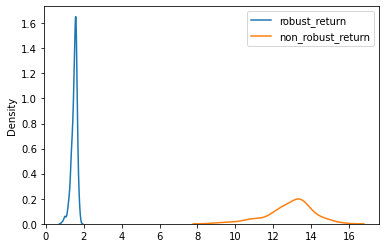

In [72]:
data1 = {'robust_return':Ex_ret_robust, 'non_robust_return':Ex_ret_non_robust}
dt1 = pd.DataFrame(data = data1)
sns.kdeplot(data = dt1)

<AxesSubplot:ylabel='Density'>

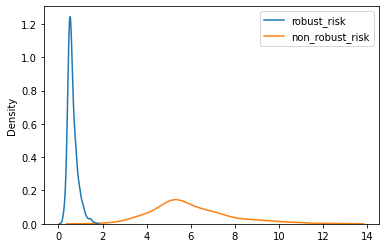

In [73]:
data2 = {'robust_risk':risk_robust, 'non_robust_risk':risk_non_robust}
dt2 = pd.DataFrame(data = data2)
sns.kdeplot(data = dt2)

In [48]:
returns

array([0.09412192, 0.10619784, 0.11525861, 0.18164125, 0.24199006,
       0.33250506, 0.39286401, 1.59984822, 2.20333612, 3.10857189,
       6.10871588])

In [45]:
len(prob)

317